## Logistic Regression

- input (X) = hours studied
- output (y): `0 = fail, 1 = pass`
- `Sigmoid` squeezes outputs between `0 and 1`
- Sigmoid converts values into probabilities between `0 and 1`.
- Instead of predicting continuous values like linear regression, logistic regression predicts probabilities:
- 0 → No, 1 → Yes

### Logistic regression is used for:
 - spam detection
 - pass/fail
 - diabetes prediction
 - fraud detection
 - spam detection
 - disease prediction
 - customer churn
 - click prediction
 - credit approval

In [11]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

print(sigmoid(torch.tensor([-10.0, -1.0, 0.0, 1.0, 10.0])))

tensor([4.5398e-05, 2.6894e-01, 5.0000e-01, 7.3106e-01, 9.9995e-01])


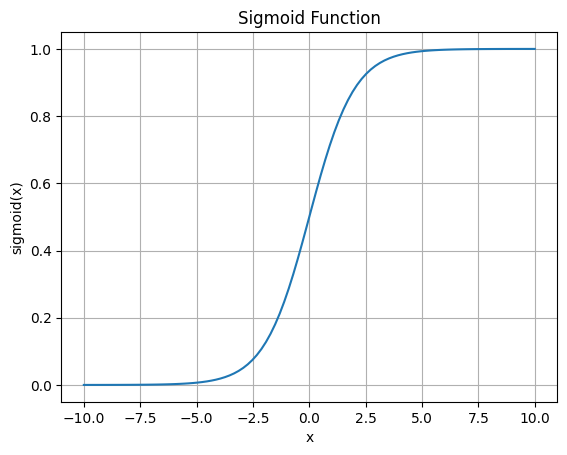

In [12]:
# plotting the sigmoid function
import matplotlib.pyplot as plt

x = torch.linspace(-10, 10, 100)
y = sigmoid(x)

plt.plot(x.numpy(), y.numpy())
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.title('Sigmoid Function')
plt.grid(True)
plt.show()

In [13]:
import torch
import torch.nn as nn

In [14]:
# Input data (hours studied)
X = torch.tensor([
    [1.0],
    [2.0],
    [3.0],
    [4.0],
    [5.0],
    [6.0]
])

# Labels
y = torch.tensor([
    [0.0],
    [0.0],
    [0.0],
    [1.0],
    [1.0],
    [1.0]
])

In [16]:
# Logistic Regression Model
class LogisticRegressionModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.linear = nn.Linear(1, 1)

    def forward(self, x):

        # Linear transformation
        logits = self.linear(x)

        # Sigmoid activation
        predictions = torch.sigmoid(logits)

        return predictions

In [17]:
# Create model
model = LogisticRegressionModel()

print(list(model.parameters()))

[Parameter containing:
tensor([[-0.1694]], requires_grad=True), Parameter containing:
tensor([-0.1290], requires_grad=True)]


In [18]:
# Loss function
loss_fn = nn.BCELoss()

# Optimizer
optimizer = torch.optim.SGD(model.parameters(),lr=0.01)

In [19]:
# Training loop
epochs = 1000

for epoch in range(epochs):

    # Forward pass
    y_pred = model(X)

    # Compute loss
    loss = loss_fn(y_pred, y)

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    # Zero gradients
    optimizer.zero_grad()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.8932
Epoch 100, Loss: 0.5821
Epoch 200, Loss: 0.5567
Epoch 300, Loss: 0.5335
Epoch 400, Loss: 0.5123
Epoch 500, Loss: 0.4927
Epoch 600, Loss: 0.4746
Epoch 700, Loss: 0.4579
Epoch 800, Loss: 0.4425
Epoch 900, Loss: 0.4282


In [20]:
# Test prediction
test = torch.tensor([[4.5]])

with torch.no_grad():

    prediction = model(test)

    print("\nProbability of passing:")
    print(prediction.item())

    # Convert probability to class
    predicted_class = 1 if prediction >= 0.5 else 0

    print("Predicted Class:", predicted_class)


Probability of passing:
0.7475920915603638
Predicted Class: 1
